# Modelling 
This notebook develops and evaluates two regression models to predict taxi drivers' earnings potential using weather severity, precipitation type, pickup location, time of day and week day. A linear regression model is first applied with LASSO regularisation. A Random Forest model is subsequently used to account for potential non-linear relationships between the predictors and earnings potential.

The models are evaluated using RMSE, MAE and R² on the held-out test dataset.

In [1]:
# Importing the libraries required throughout the notebook
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

import pandas as pd
import matplotlib.pyplot as plt

# Initialising the Spark session for modelling
spark = (
    SparkSession.builder
    .appName("MAST30034_Project1_models")
    .config("spark.driver.memory", "1500m")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

# Loading the aggregated training and test datasets
train_agg = spark.read.parquet("../data/processed/train_agg.parquet")
test_agg = spark.read.parquet("../data/processed/test_agg.parquet")

print(f"Training rows: {train_agg.count():,}")
print(f"Testing rows:  {test_agg.count():,}")

print("\nTraining columns:")
print(train_agg.columns)

print("\nTesting columns:")
print(test_agg.columns)

# Defining the categorical, continuous and target variables
categorical_columns = ["PULocationID", "time_of_day", "week_day", "precip_type"]

continuous_columns = ["avg_severity_score"]

target_column = "adj_earnings_potential"

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/08/31 18:51:18 WARN Utils: Your hostname, MAHIKA-F8R8E40, resolves to a loopback address: 127.0.1.1; using 192.168.16.49 instead (on interface eth0)
26/08/31 18:51:18 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/31 18:51:22 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Training rows: 32,983
Testing rows:  16,320

Training columns:
['PULocationID', 'severity_cat', 'week_day', 'precip_type', 'time_of_day', 'total_fare', 'total_duration_min', 'trip_count', 'avg_severity_score', 'earnings_potential', 'adj_earnings_potential']

Testing columns:
['PULocationID', 'severity_cat', 'week_day', 'precip_type', 'time_of_day', 'total_fare', 'total_duration_min', 'trip_count', 'avg_severity_score', 'earnings_potential', 'adj_earnings_potential']


## 1. LASSO Regression Model

In [2]:
# Encoding categorical variables
lasso_indexers = [
    StringIndexer(
        inputCol=col,
        outputCol=f"{col}_idx",
        handleInvalid="keep"
    )
    for col in categorical_columns
]

lasso_encoders = [
    OneHotEncoder(
        inputCol=f"{col}_idx",
        outputCol=f"{col}_vec"
    )
    for col in categorical_columns
]

# Combining all variables into a feature vector
lasso_assembler = VectorAssembler(
    inputCols=(
        continuous_columns +
        [f"{col}_vec" for col in categorical_columns]
    ),
    outputCol="features"
)

# Initialising a linear regression model with L1 (LASSO) regularisation
lasso_model = LinearRegression(
    featuresCol="features",
    labelCol=target_column,
    elasticNetParam=1.0
)

# Combining indexing, one-hot encoding, feature assembly and the LASSO model into a pipeline
lasso_pipeline = Pipeline(
    stages=lasso_indexers + lasso_encoders + [lasso_assembler, lasso_model]
)

# Defining the hyperparameters to compare during cross-validation
lasso_param_grid = (
    ParamGridBuilder()
    .addGrid(lasso_model.regParam, [0.005, 0.01, 0.05, 0.1])
    .build()
)

# Setting RMSE as the metric for selecting the best model
rmse_evaluator = RegressionEvaluator(
    labelCol=target_column,
    predictionCol="prediction",
    metricName="rmse"
)

# Performing 3-fold cross-validation for hyperparameter tuning
lasso_cv = CrossValidator(
    estimator=lasso_pipeline,
    estimatorParamMaps=lasso_param_grid,
    evaluator=rmse_evaluator,
    numFolds=3,
    seed=42
)

lasso_cv_model = lasso_cv.fit(train_agg)

# Extracting the best LASSO model 
best_lasso_model = lasso_cv_model.bestModel
best_lasso = best_lasso_model.stages[-1]

print(f"Best regParam = {best_lasso.getOrDefault('regParam')}")

# Using the best model to generate predictions on the held-out test set
lasso_test_predictions = lasso_cv_model.transform(test_agg)

# Defining evaluators for MAE and R²
mae_evaluator = RegressionEvaluator(
    labelCol=target_column,
    predictionCol="prediction",
    metricName="mae"
)

r2_evaluator = RegressionEvaluator(
    labelCol=target_column,
    predictionCol="prediction",
    metricName="r2"
)

# Evaluating the best LASSO model on the test dataset
lasso_rmse = rmse_evaluator.evaluate(lasso_test_predictions)
lasso_mae = mae_evaluator.evaluate(lasso_test_predictions)
lasso_r2 = r2_evaluator.evaluate(lasso_test_predictions)

# Counting the number of non-zero coefficients retained
non_zero = sum(
    abs(float(coef)) > 1e-8
    for coef in best_lasso.coefficients
)

print("LASSO Model Performance metrics:")
print(f"Test RMSE = {lasso_rmse:.4f}")
print(f"Test MAE  = {lasso_mae:.4f}")
print(f"Test R²   = {lasso_r2:.4f}")
print(f"Non-zero coefficients = {non_zero}")

netlib-blas: JNI_OnLoad: dlopen(libblas.so.3) failed: libblas.so.3: cannot open shared object file: No such file or directory


Best regParam = 0.01
LASSO Model Performance metrics:
Test RMSE = 5.1241
Test MAE  = 3.8132
Test R²   = 0.5632
Non-zero coefficients = 247


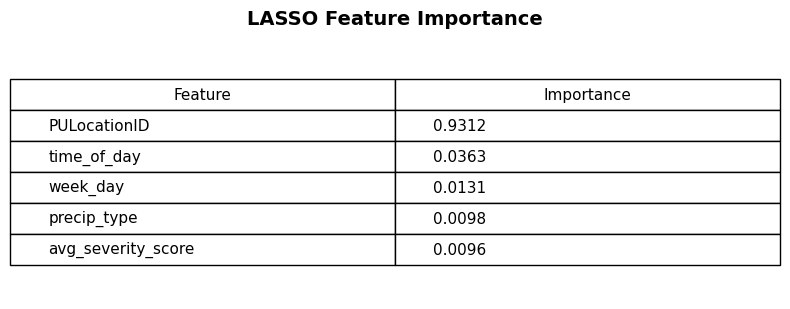

In [3]:
# Extracting the names of the encoded features
best_lasso_prepared = best_lasso_model.transform(train_agg)

feature_metadata = best_lasso_prepared.schema["features"].metadata
feature_attributes = feature_metadata["ml_attr"]["attrs"]

feature_names_dict = {}

for attribute_type in ["numeric", "binary"]:
    for attr in feature_attributes.get(attribute_type, []):
        feature_names_dict[attr["idx"]] = attr["name"]

encoded_feature_names = [
    feature_names_dict[i]
    for i in sorted(feature_names_dict)
]

# Creating a dataframe containing each encoded feature and its coefficient
lasso_coefficients = best_lasso.coefficients.toArray()

lasso_coef_df = pd.DataFrame({
    "Encoded_Feature": encoded_feature_names,
    "Coefficient": lasso_coefficients
})

def get_original_feature(feature):

    """
    This function maps the encoded feature name to its corresponding original feature name.

    Parameters: 
    feature: The encoded feature 

    Returns: 
    The corresponding feature name

    """

    if feature.startswith("PULocationID_vec"):
        return "PULocationID"
    elif feature.startswith("time_of_day_vec"):
        return "time_of_day"
    elif feature.startswith("week_day_vec"):
        return "week_day"
    elif feature.startswith("precip_type_vec"):
        return "precip_type"
    elif feature == "avg_severity_score":
        return "avg_severity_score"
    else:
        return feature

lasso_coef_df["Feature"] = lasso_coef_df["Encoded_Feature"].apply(get_original_feature)

# Grouping encoded features by their original feature and 
# summing the absolute values of their coefficients
lasso_importance = (
    lasso_coef_df
    .assign(Absolute_Coefficient=lasso_coef_df["Coefficient"].abs())
    .groupby("Feature")["Absolute_Coefficient"]
    .sum()
    .reset_index()
)

# Calculating the relative importance of each feature
# by dividing its summed absolute coefficient by the sum across all features 
lasso_importance["Importance"] = (
    lasso_importance["Absolute_Coefficient"]
    / lasso_importance["Absolute_Coefficient"].sum()
)

# Ordering variables from most to least important
lasso_importance = (
    lasso_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

lasso_importance["Importance"] = (lasso_importance["Importance"].round(4))

lasso_importance = lasso_importance[["Feature", "Importance"]]

# Plotting the relative importance of the features
fig, ax = plt.subplots(figsize=(8, 3.2))

ax.axis("off")

lasso_table = ax.table(
    cellText=lasso_importance[["Feature", "Importance"]].values,
    colLabels=["Feature", "Importance"],
    cellLoc="left",
    loc="center"
)

lasso_table.auto_set_font_size(False)
lasso_table.set_fontsize(11)
lasso_table.scale(1, 1.8)

plt.title("LASSO Feature Importance", fontsize=14, pad=15, fontweight='bold')

plt.tight_layout()

plt.savefig("../outputs/lasso_feature_importance.png", dpi=200, bbox_inches="tight")

plt.show()

## 2. Random Forest Model 

In [4]:
# Encoding categorical variables
rf_indexers = [
    StringIndexer(
        inputCol=col,
        outputCol=f"{col}_idx",
        handleInvalid="keep"
    )
    for col in categorical_columns
]

# Combining all variables into a feature vector
rf_assembler = VectorAssembler(
    inputCols=(
        continuous_columns +
        [f"{col}_idx" for col in categorical_columns]
    ),
    outputCol="features"
)

# Initialising a Random Forest regression model
rf_model = RandomForestRegressor(
    featuresCol="features",
    labelCol=target_column,
    numTrees=100,
    maxDepth=8,
    maxBins=300,
    seed=42
)

# Combining indexing, feature assembly and the Random Forest model into a pipeline
rf_pipeline = Pipeline(stages=rf_indexers + [rf_assembler, rf_model])

# Defining the hyperparameters to compare during cross-validation
rf_param_grid = (
    ParamGridBuilder()
    .addGrid(rf_model.numTrees, [50, 100])
    .addGrid(rf_model.maxDepth, [5, 8, 10])
    .build()
)

# Performing 3-fold cross-validation for hyperparameter tuning
rf_cv = CrossValidator(
    estimator=rf_pipeline,
    estimatorParamMaps=rf_param_grid,
    evaluator=rmse_evaluator,
    numFolds=3,
    seed=42
)

rf_cv_model = rf_cv.fit(train_agg)

# Extracting the best Random Forest model
best_rf_model = rf_cv_model.bestModel
best_rf = best_rf_model.stages[-1]

print(f"Number of trees in best model: {best_rf.getNumTrees}")
print(f"Maximum depth in best model:  {best_rf.getOrDefault('maxDepth')}")

# Using the best model to generate predictions on the held-out test set
rf_test_predictions = rf_cv_model.transform(test_agg)

# Evaluating the best Random Forest model on the test dataset
rf_rmse = rmse_evaluator.evaluate(rf_test_predictions)
rf_mae = mae_evaluator.evaluate(rf_test_predictions)
rf_r2 = r2_evaluator.evaluate(rf_test_predictions)

print("Random Forest Model Performance metrics:")
print(f"Test RMSE = {rf_rmse:.4f}")
print(f"Test MAE  = {rf_mae:.4f}")
print(f"Test R²   = {rf_r2:.4f}")

Number of trees in best model: 100
Maximum depth in best model:  10


Random Forest Model Performance metrics:
Test RMSE = 4.0119
Test MAE  = 2.9248
Test R²   = 0.7322


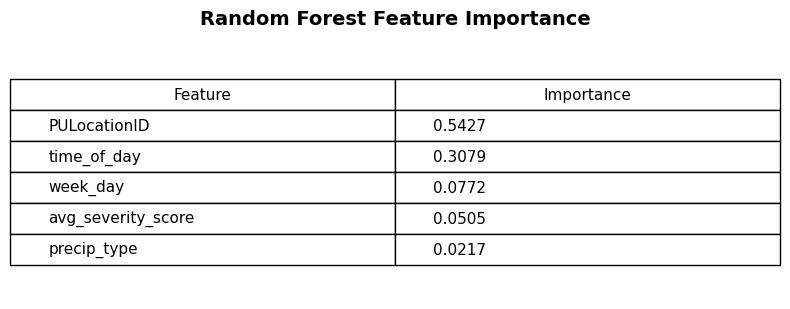

In [5]:
# Sorting model features by their importance
rf_feature_importance = sorted(
    zip(
        continuous_columns + [f"{col}_idx" for col in categorical_columns],
        best_rf.featureImportances
    ),
    key=lambda x: x[1],
    reverse=True
)

# Mapping feature names to their original names
feature_name_map = {
    "avg_severity_score": "avg_severity_score",
    "PULocationID_idx": "PULocationID",
    "time_of_day_idx": "time_of_day",
    "week_day_idx": "week_day",
    "precip_type_idx": "precip_type"
}

rf_importance = pd.DataFrame(
    rf_feature_importance,
    columns=["Feature", "Importance"]
)

rf_importance["Feature"] = (
    rf_importance["Feature"].map(feature_name_map)
)

rf_importance["Importance"] = (
    rf_importance["Importance"].round(4)
)

# Plotting the relative importance of the features
fig, ax = plt.subplots(figsize=(8, 3.2))

ax.axis("off")

rf_table = ax.table(
    cellText=rf_importance.values,
    colLabels=["Feature", "Importance"],
    cellLoc="left",
    loc="center"
)

rf_table.auto_set_font_size(False)
rf_table.set_fontsize(11)
rf_table.scale(1, 1.8)

plt.title("Random Forest Feature Importance", fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig("../outputs/rf_feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()

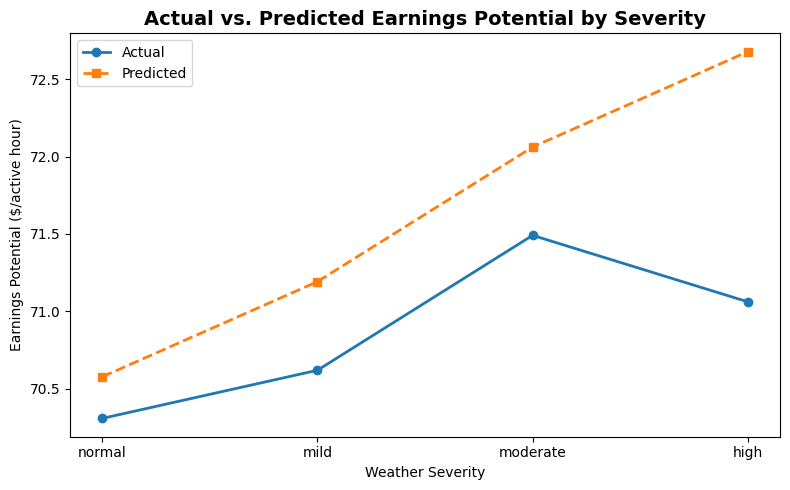

In [6]:
# Calculating average actual and predicted earnings potential by weather severity
prediction_comparison = (
    rf_test_predictions
    .groupBy("severity_cat")
    .agg(
        F.avg(target_column).alias("actual_mean"),
        F.avg("prediction").alias("predicted_mean")
    )
    .toPandas()
)

# Ordering weather severity categories
severity_order = ["normal", "mild", "moderate", "high"]

prediction_comparison["severity_cat"] = pd.Categorical(
    prediction_comparison["severity_cat"],
    categories=severity_order,
    ordered=True
)

prediction_comparison = prediction_comparison.sort_values("severity_cat")

# Plotting actual vs predicted earnings potential by weather severity
fig, ax = plt.subplots(figsize=(8, 5))

x = range(len(prediction_comparison))

ax.plot(
    x,
    prediction_comparison["actual_mean"],
    marker="o",
    linewidth=2,
    label="Actual"
)

ax.plot(
    x,
    prediction_comparison["predicted_mean"],
    marker="s",
    linewidth=2,
    linestyle="--",
    label="Predicted"
)

ax.set_xticks(x)
ax.set_xticklabels(prediction_comparison["severity_cat"])

ax.set_xlabel("Weather Severity")
ax.set_ylabel("Earnings Potential ($/active hour)")

ax.set_title("Actual vs. Predicted Earnings Potential by Severity", fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()

plt.savefig("../outputs/rf_actual_vs_predicted_severity.png", dpi=150, bbox_inches="tight")

plt.show()